In [15]:
import pandas as pd, numpy as np
import argparse
import pickle
import ast
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
import os
import re
from collections import defaultdict

# Utility functions

In [16]:
def pickle_to_res(path):
    with open(path, "rb") as f:
        raw_pickle = pickle.load(f)
    results = {}
    answer_prefix="Answer Choice "

    def extract_ans(ans_str, search_substring):
        # Split the string into lines
        lines = ans_str.split("\n")

        for line in lines:
            # Check if the line starts with the specified substring
            if line.startswith(search_substring):
                # If it does, add it to the list of extracted rows
                return line[len(search_substring) :].strip()
        return "ERROR"  # Answer not found

    for k, v in raw_pickle.items():
        if k != 'token_usage':  # Skip token_usage
            qns_idx = ast.literal_eval(k)
            for idx, qn_idx in enumerate(qns_idx):
                results[qn_idx] = extract_ans(
                    v[0], f"{answer_prefix}{idx+1}:"
                )  # We start with question 1
    
    return results

In [17]:
# Count number of 56 and malignant in test_metadata.csv

test_df = pd.read_csv('C:/Users/sonne/Documents/Github/biasICL/ddi_test_metadata.csv', index_col=0)

rare_diseases = {
        'subcutaneous-t-cell-lymphoma', 'focal-acral-hyperkeratosis', 
        'eccrine-poroma', 'inverted-follicular-keratosis', 'kaposi-sarcoma',
        'metastatic-carcinoma', 'mycosis-fungoides', 
        'acquired-digital-fibrokeratoma', 'atypical-spindle-cell-nevus-of-reed',
        'verruciform-xanthoma', 'morphea', 'nevus-lipomatosus-superficialis',
        'pigmented-spindle-cell-nevus-of-reed', 'arteriovenous-hemangioma',
        'syringocystadenoma-papilliferum', 'trichofolliculoma',
        'coccidioidomycosis', 'leukemia-cutis', 'sebaceous-carcinoma',
        'blastic-plasmacytoid-dendritic-cell-neoplasm', 'glomangioma',
        'dermatomyositis', 'cellular-neurothekeoma', 'graft-vs-host-disease',
        'xanthograngioma', 'chondroid-syringoma', 'angioleiomyoma'
    }

test_df = test_df[~test_df.disease.isin(rare_diseases)]

print("number of fst 12", len(test_df[test_df.skin_tone == 12]))
print("number of fst 56", len(test_df[test_df.skin_tone == 56]))

print(f'Number of 56 and malignant: {len(test_df[(test_df.skin_tone == 56) & (test_df.malignant)])}')
print(f'Number of 12 and malignant: {len(test_df[(test_df.skin_tone == 12) & (test_df.malignant)])}')

print(f'Number of 56 and benign: {len(test_df[(test_df.skin_tone == 56) &  (~test_df.malignant)])}')
print(f'Number of 12 and benign: {len(test_df[(test_df.skin_tone == 12) & (~test_df.malignant)])}')

number of fst 12 44
number of fst 56 39
Number of 56 and malignant: 7
Number of 12 and malignant: 10
Number of 56 and benign: 32
Number of 12 and benign: 34


In [18]:
def res_to_vec(res):
    test_df = pd.read_csv('C:/Users/sonne/Documents/Github/biasICL/ddi_test_metadata.csv', index_col=0)
    num_errors = 0
    labels, preds, race = [], [], []
    for i in test_df.itertuples():
        fst = '12' if i.skin_tone == 12 else '56'
        if (i.Index not in res) or (res[i.Index].startswith("ERROR")):
            num_errors += 1

            print(i.Index, f"answer not found")
            continue

        pred_text = res[i.Index]
        ground_truth = "B" if i.malignant == True else "A"
        labels.append(ground_truth)
        preds.append(pred_text)
        race.append(fst)
        
    print(f"In total {num_errors} errors len = {len(labels)}")
    return labels,preds,race

In [19]:
def calculate_avg_prediction(labels, preds):
    # Convert 'A' to 0 and 'B' to 1
    label_map = {'A': 0, 'B': 1}
    
    # Map the labels and predictions to numeric values
    numeric_preds = [label_map[p] for p in preds]
    numeric_labels = [label_map[l] for l in labels]
    
    # Calculate the average of the predictions and labels
    avg_preds = np.mean(numeric_preds)
    avg_labels = np.mean(numeric_labels)
    
    return avg_preds, avg_labels


In [20]:
def calculate_metrics_across_replicates(exp_lists):
    """
    Calculate metrics across technical replicates
    
    Parameters:
    exp_lists: List of 3 lists, where each inner list contains experiments for one technical replicate
               Corresponding experiments should be in the same order in each replicate list
    
    Returns:
    Dictionaries containing means and standard errors for bulk, FST 1/2, and FST 5/6 metrics
    """
    # Initialize data structures for each metric type
    bulk_metrics = {'mean': [], 'stderr': []}
    fst12_metrics = {'mean': [], 'stderr': []}
    fst56_metrics = {'mean': [], 'stderr': []}
    
    # Get number of experiments in each replicate
    n_experiments = len(exp_lists[0])
    
    # For each experiment position
    for exp_idx in range(n_experiments):
        # Storage for metrics from each replicate
        bulk_replicate_metrics = []
        fst12_replicate_metrics = []
        fst56_replicate_metrics = []
        
        # Process each replicate
        for replicate_list in exp_lists:
            exp = replicate_list[exp_idx]
            results = pickle_to_res(exp)
            print(exp)
            labels, preds, race = res_to_vec(results)
            
            # Calculate bulk metrics
            accuracy, tpr, tnr, fscore = calculate_metrics(labels, preds)
            avg_preds, avg_labels = calculate_avg_prediction(labels, preds)
            bulk_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore,
                'avg_preds': avg_preds,
                'avg_labels': avg_labels
            })
            
            # Calculate FST 1/2 metrics
            fst12_labels, fst12_preds = filter_by_race(labels, preds, race, '12')
            accuracy, tpr, tnr, fscore = calculate_metrics(fst12_labels, fst12_preds)
            avg_fst12_preds, avg_fst12_labels = calculate_avg_prediction(fst12_labels, fst12_preds)
            fst12_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore,
                'avg_preds': avg_fst12_preds,
                'avg_labels': avg_fst12_labels
            })
            
            # Calculate FST 5/6 metrics
            fst56_labels, fst56_preds = filter_by_race(labels, preds, race, '56')
            accuracy, tpr, tnr, fscore = calculate_metrics(fst56_labels, fst56_preds)
            avg_fst56_preds, avg_fst56_labels = calculate_avg_prediction(fst56_labels, fst56_preds)
            fst56_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore,
                'avg_preds': avg_fst56_preds,
                'avg_labels': avg_fst56_labels
            })
        
        # Calculate means and standard errors across replicates
        def calc_mean_stderr(replicate_data, metric):
            values = [rep[metric] for rep in replicate_data]
            return np.mean(values), np.std(values) / np.sqrt(len(values))
        
        # Process bulk metrics
        bulk_means = {}
        bulk_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore', 'avg_preds', 'avg_labels']:
            mean, stderr = calc_mean_stderr(bulk_replicate_metrics, metric)
            bulk_means[metric] = mean
            bulk_stderrs[metric] = stderr
        bulk_metrics['mean'].append(bulk_means)
        bulk_metrics['stderr'].append(bulk_stderrs)
        
        # Process FST 1/2 metrics
        fst12_means = {}
        fst12_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore', 'avg_preds', 'avg_labels']:
            mean, stderr = calc_mean_stderr(fst12_replicate_metrics, metric)
            fst12_means[metric] = mean
            fst12_stderrs[metric] = stderr
        fst12_metrics['mean'].append(fst12_means)
        fst12_metrics['stderr'].append(fst12_stderrs)
        
        # Process FST 5/6 metrics
        fst56_means = {}
        fst56_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore', 'avg_preds', 'avg_labels']:
            mean, stderr = calc_mean_stderr(fst56_replicate_metrics, metric)
            fst56_means[metric] = mean
            fst56_stderrs[metric] = stderr
        fst56_metrics['mean'].append(fst56_means)
        fst56_metrics['stderr'].append(fst56_stderrs)
    
    return bulk_metrics, fst12_metrics, fst56_metrics

def calculate_metrics(actual, predicted):
    TP = sum((a == 'B' and p == 'B') for a, p in zip(actual, predicted))
    TN = sum((a == 'A' and p == 'A') for a, p in zip(actual, predicted))
    FP = sum((a == 'A' and p == 'B') for a, p in zip(actual, predicted))
    FN = sum((a == 'B' and p == 'A') for a, p in zip(actual, predicted))
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    # Calculate F1 score
    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0
    
    accuracy = (TP + TN) / len(actual) if len(actual) > 0 else 0
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return accuracy, tpr, tnr, f1_score



def filter_by_race(actual, predicted, race, race_value):
    filtered_actual = [a for a, r in zip(actual, race) if r == race_value]
    filtered_predicted = [p for p, r in zip(predicted, race) if r == race_value]
    return filtered_actual, filtered_predicted

In [21]:
def plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, title, use_error_bars=False):
    """
    Plot all experiment metrics (accuracy, TPR, F-score) in a single figure with multiple rows
    
    Parameters:
    bulk_metrics, fst12_metrics, fst56_metrics: dictionaries containing means and standard deviations/errors
    shots: list of integers representing the number of shots for each experiment
    title: string for the overall figure title
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    # Create figure with 2 rows and 2 columns
    fig = plt.figure(figsize=(12, 9))
    
    # Create gridspec with adjusted spacing
    gs = fig.add_gridspec(2, 2, 
                         height_ratios=[1, 1], 
                         top=0.85,      # Space for title
                         bottom=0.1,    # Space for bottom labels
                         left=0.1,      # Space for left labels
                         right=0.9,     # Space for right margin
                         hspace=0.25,   # Increased vertical space between subplots
                         wspace=0.20)   # Space between columns
    
    axes = []
    for i in range(2):
        row = []
        for j in range(2):
            row.append(fig.add_subplot(gs[i, j]))
        axes.append(row)
    axes = np.array(axes)
    
    # Add title with padding
    fig.suptitle(title, fontsize=16, y=0.93)
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    metrics = ['accuracy', 'fscore']
    
    for idx, score_type in enumerate(metrics):
        # Extract means and standard deviations for current metric
        print(bulk_metrics['mean'], fst12_metrics['mean'], fst56_metrics['mean'])
        bulk_means = [m[score_type] for m in bulk_metrics['mean']]
        bulk_stds = [s[score_type] for s in bulk_metrics['stderr']]

        fst12_means = [m[score_type] for m in fst12_metrics['mean']]
        fst12_stds = [s[score_type] for s in fst12_metrics['stderr']]
        
        fst56_means = [m[score_type] for m in fst56_metrics['mean']]
        fst56_stds = [s[score_type] for s in fst56_metrics['stderr']]
        
        # Left plot (metrics)
        if use_error_bars:
            axes[idx, 0].errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                                color=line_colors[0], label=f'Aggregate {score_type}', 
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst12_means, yerr=fst12_stds, fmt='s-',
                                color=line_colors[1], label=f'FST 1/2 {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst56_means, yerr=fst56_stds, fmt='^-',
                                color=line_colors[2], label=f'FST 5/6 {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 0].plot(shots, bulk_means, 'o-', color=line_colors[0], 
                            label=f'Aggregate {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots, 
                                    np.array(bulk_means) - np.array(bulk_stds),
                                    np.array(bulk_means) + np.array(bulk_stds),
                                    color=line_colors[0], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst12_means, 's-', color=line_colors[1], 
                            label=f'FST 1/2 {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst12_means) - np.array(fst12_stds),
                                    np.array(fst12_means) + np.array(fst12_stds),
                                    color=line_colors[1], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst56_means, '^-', color=line_colors[2], 
                            label=f'FST 5/6 {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst56_means) - np.array(fst56_stds),
                                    np.array(fst56_means) + np.array(fst56_stds),
                                    color=line_colors[2], alpha=0.2)
        
        axes[idx, 0].set_xlabel('Number of Shots')
        axes[idx, 0].set_ylabel(score_type.upper())
        axes[idx, 0].set_title(f'{score_type.upper()} by Number of Shots and Skin Type')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, linestyle='--', alpha=0.7)
        
        # Right plot (bias)
        biases_mean = np.array(fst12_means) - np.array(fst56_means)
        biases_std = np.sqrt(np.array(fst12_stds)**2 + np.array(fst56_stds)**2)  # Error propagation
        
        if use_error_bars:
            axes[idx, 1].errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                                color='purple', label=f'Bias (FST 1/2 - FST 5/6 {score_type})',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 1].plot(shots, biases_mean, 'o-', color='purple', 
                            label=f'Bias (FST 1/2 - FST 5/6 {score_type})', linewidth=2)
            axes[idx, 1].fill_between(shots,
                                    biases_mean - biases_std,
                                    biases_mean + biases_std,
                                    color='purple', alpha=0.2)
        
        axes[idx, 1].set_xlabel('Number of Shots')
        axes[idx, 1].set_ylabel('Bias')
        axes[idx, 1].set_title(f'Bias in {score_type.upper()} by Number of Shots')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, linestyle='--', alpha=0.7)    
    
    plt.show()

In [22]:
def plot_all_avg_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, title, use_error_bars=False):
    """
    Plot all experiment metrics (accuracy, TPR, F-score) in a single figure with multiple rows
    
    Parameters:
    bulk_metrics, fst12_metrics, fst56_metrics: dictionaries containing means and standard deviations/errors
    shots: list of integers representing the number of shots for each experiment
    title: string for the overall figure title
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    # Create figure with 2 rows and 2 columns
    fig = plt.figure(figsize=(12, 9))
    
    # Create gridspec with adjusted spacing
    gs = fig.add_gridspec(2, 2, 
                         height_ratios=[1, 1], 
                         top=0.85,      # Space for title
                         bottom=0.1,    # Space for bottom labels
                         left=0.1,      # Space for left labels
                         right=0.9,     # Space for right margin
                         hspace=0.25,   # Increased vertical space between subplots
                         wspace=0.20)   # Space between columns
    
    axes = []
    for i in range(2):
        row = []
        for j in range(2):
            row.append(fig.add_subplot(gs[i, j]))
        axes.append(row)
    axes = np.array(axes)
    
    # Add title with padding
    fig.suptitle(title, fontsize=16, y=0.93)
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    metrics = ['avg_preds', 'avg_labels']
    
    for idx, score_type in enumerate(metrics):
        # Extract means and standard deviations for current metric
        print(bulk_metrics['mean'], fst12_metrics['mean'], fst56_metrics['mean'])
        bulk_means = [m[score_type] for m in bulk_metrics['mean']]
        bulk_stds = [s[score_type] for s in bulk_metrics['stderr']]

        fst12_means = [m[score_type] for m in fst12_metrics['mean']]
        fst12_stds = [s[score_type] for s in fst12_metrics['stderr']]
        
        fst56_means = [m[score_type] for m in fst56_metrics['mean']]
        fst56_stds = [s[score_type] for s in fst56_metrics['stderr']]
        
        # Left plot (metrics)
        if use_error_bars:
            axes[idx, 0].errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                                color=line_colors[0], label=f'Aggregate {score_type}', 
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst12_means, yerr=fst12_stds, fmt='s-',
                                color=line_colors[1], label=f'FST 1/2 {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst56_means, yerr=fst56_stds, fmt='^-',
                                color=line_colors[2], label=f'FST 5/6 {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 0].plot(shots, bulk_means, 'o-', color=line_colors[0], 
                            label=f'Aggregate {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots, 
                                    np.array(bulk_means) - np.array(bulk_stds),
                                    np.array(bulk_means) + np.array(bulk_stds),
                                    color=line_colors[0], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst12_means, 's-', color=line_colors[1], 
                            label=f'FST 1/2 {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst12_means) - np.array(fst12_stds),
                                    np.array(fst12_means) + np.array(fst12_stds),
                                    color=line_colors[1], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst56_means, '^-', color=line_colors[2], 
                            label=f'FST 5/6 {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst56_means) - np.array(fst56_stds),
                                    np.array(fst56_means) + np.array(fst56_stds),
                                    color=line_colors[2], alpha=0.2)
        
        axes[idx, 0].set_xlabel('Number of Shots')
        axes[idx, 0].set_ylabel(score_type.upper())
        axes[idx, 0].set_title(f'{score_type.upper()} by Number of Shots and Skin Type')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, linestyle='--', alpha=0.7)
        
        # Right plot (bias)
        biases_mean = np.array(fst12_means) - np.array(fst56_means)
        biases_std = np.sqrt(np.array(fst12_stds)**2 + np.array(fst56_stds)**2)  # Error propagation
        
        if use_error_bars:
            axes[idx, 1].errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                                color='purple', label=f'Bias (FST 1/2 - FST 5/6 {score_type})',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 1].plot(shots, biases_mean, 'o-', color='purple', 
                            label=f'Bias (FST 1/2 - FST 5/6 {score_type})', linewidth=2)
            axes[idx, 1].fill_between(shots,
                                    biases_mean - biases_std,
                                    biases_mean + biases_std,
                                    color='purple', alpha=0.2)
        
        axes[idx, 1].set_xlabel('Number of Shots')
        axes[idx, 1].set_ylabel('Bias')
        axes[idx, 1].set_title(f'Bias in {score_type.upper()} by Number of Shots')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, linestyle='--', alpha=0.7)    
    
    plt.show()

# plot increasing demos

In [23]:
# Parameters for customization
base_path = "C:/Users/sonne/Downloads"
# rep_folders = ["claude0104", "claude1217", "claude1131"]  # Subfolders for each replicate
# rep_folders = ["gemini0110", "gemini0111", "gemini0112"]
# rep_folders = ["gpt4o0122"]
# model_name = "gpt-4o-2024-05-13"
model_name = "Gemini1.5"
rep_folders = ["fst0129"]
# model_name = "o1-2024-12-17"  # Model name
# numbers = [(0, 0), (8, 8), (16, 16), (32, 32)]  # Number of shots
numbers = ["0_0", "8_8", "16_16", "32_32"]


In [24]:
# Generate the experiment lists dynamically
exps_list = [
    [f"{base_path}/{folder}/ddi_fst_{num}_{model_name}_50.pkl" for num in numbers]
    for folder in rep_folders
]

# Unpacking individual lists for convenience (optional)
exps_rep_1, exps_rep_2, exps_rep_3 = exps_list, exps_list, exps_list

# Output for verification
print("exps_rep_1:", exps_rep_1)
print("exps_rep_2:", exps_rep_2)
print("exps_rep_3:", exps_rep_3)

exps_rep_1: [['C:/Users/sonne/Downloads/fst0129/ddi_fst_0_0_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_8_8_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_16_16_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_32_32_Gemini1.5_50.pkl']]
exps_rep_2: [['C:/Users/sonne/Downloads/fst0129/ddi_fst_0_0_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_8_8_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_16_16_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_32_32_Gemini1.5_50.pkl']]
exps_rep_3: [['C:/Users/sonne/Downloads/fst0129/ddi_fst_0_0_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_8_8_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_16_16_Gemini1.5_50.pkl', 'C:/Users/sonne/Downloads/fst0129/ddi_fst_32_32_Gemini1.5_50.pkl']]


In [25]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

C:/Users/sonne/Downloads/fst0129/ddi_fst_0_0_Gemini1.5_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/fst0129/ddi_fst_8_8_Gemini1.5_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/fst0129/ddi_fst_16_16_Gemini1.5_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/fst0129/ddi_fst_32_32_Gemini1.5_50.pkl
In total 0 errors len = 104


In [26]:
print((bulk_metrics), (fst12_metrics), (fst56_metrics))

{'mean': [{'accuracy': np.float64(0.6057692307692307), 'tpr': np.float64(0.5384615384615384), 'fscore': np.float64(0.4057971014492754), 'avg_preds': np.float64(0.41346153846153844), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.6346153846153846), 'tpr': np.float64(0.4230769230769231), 'fscore': np.float64(0.3666666666666667), 'avg_preds': np.float64(0.3269230769230769), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.6057692307692307), 'tpr': np.float64(0.5), 'fscore': np.float64(0.38805970149253727), 'avg_preds': np.float64(0.3942307692307692), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.5961538461538461), 'tpr': np.float64(0.4230769230769231), 'fscore': np.float64(0.34375), 'avg_preds': np.float64(0.36538461538461536), 'avg_labels': np.float64(0.25)}], 'stderr': [{'accuracy': np.float64(0.0), 'tpr': np.float64(0.0), 'fscore': np.float64(0.0), 'avg_preds': np.float64(0.0), 'avg_labels': np.float64(0.0)}, {'accuracy': np.float64(0.0), 'tpr': np.fl

[0, 8, 16, 32]
[{'accuracy': np.float64(0.6057692307692307), 'tpr': np.float64(0.5384615384615384), 'fscore': np.float64(0.4057971014492754), 'avg_preds': np.float64(0.41346153846153844), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.6346153846153846), 'tpr': np.float64(0.4230769230769231), 'fscore': np.float64(0.3666666666666667), 'avg_preds': np.float64(0.3269230769230769), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.6057692307692307), 'tpr': np.float64(0.5), 'fscore': np.float64(0.38805970149253727), 'avg_preds': np.float64(0.3942307692307692), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.5961538461538461), 'tpr': np.float64(0.4230769230769231), 'fscore': np.float64(0.34375), 'avg_preds': np.float64(0.36538461538461536), 'avg_labels': np.float64(0.25)}] [{'accuracy': np.float64(0.7884615384615384), 'tpr': np.float64(0.08333333333333333), 'fscore': np.float64(0.15384615384615385), 'avg_preds': np.float64(0.019230769230769232), 'avg_labels': n

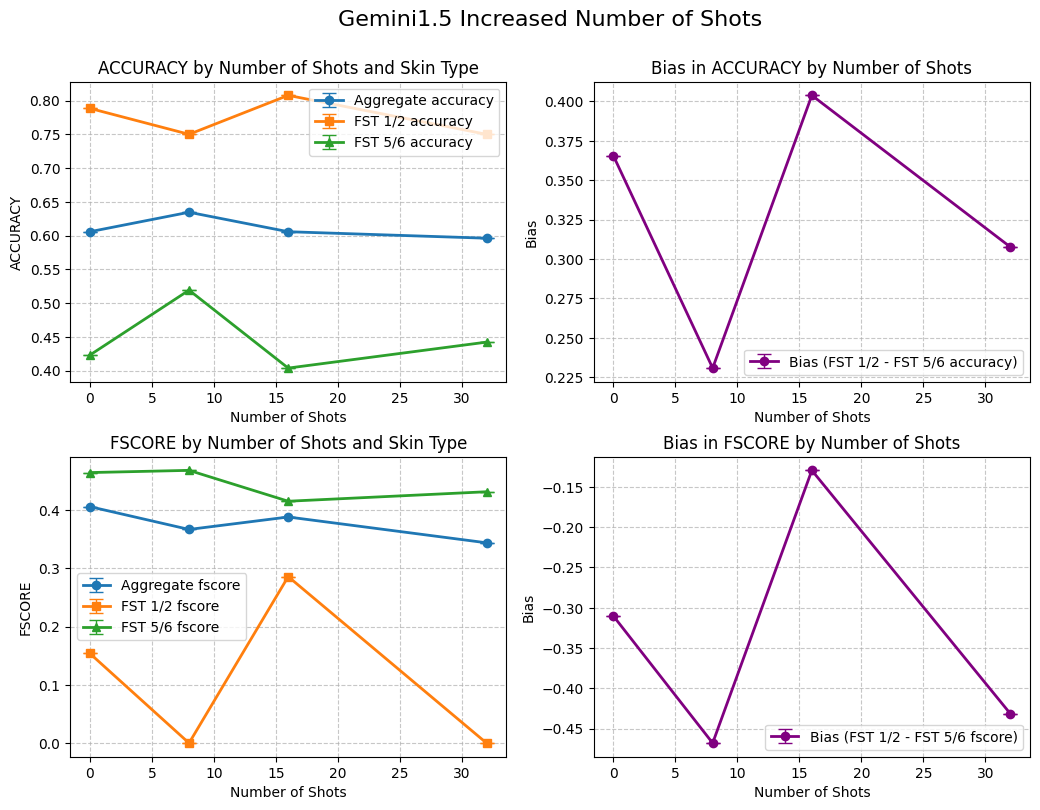

In [29]:
# Plot with confidence intervals
shots = [0, 8, 16, 32]
print(shots)
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          model_name + " Increased Number of Shots", 
                          use_error_bars=True)

In [28]:
# Generate the experiment lists dynamically
exps_list = [
    [f"{base_path}/{folder}/ddi_{num}_{model_name}_50.pkl" for num in numbers["fst12"]]
    for folder in rep_folders
]

TypeError: list indices must be integers or slices, not str

In [60]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

C:/Users/sonne/Downloads/o10122/ddi_0_0_0_0_o1-2024-12-17_50.pkl
0 answer not found
1 answer not found
2 answer not found
3 answer not found
4 answer not found
5 answer not found
6 answer not found
7 answer not found
8 answer not found
9 answer not found
10 answer not found
11 answer not found
12 answer not found
13 answer not found
14 answer not found
15 answer not found
16 answer not found
17 answer not found
18 answer not found
19 answer not found
20 answer not found
21 answer not found
22 answer not found
23 answer not found
24 answer not found
25 answer not found
26 answer not found
27 answer not found
28 answer not found
29 answer not found
30 answer not found
31 answer not found
In total 32 errors len = 0
C:/Users/sonne/Downloads/o10122/ddi_3_1_0_0_o1-2024-12-17_50.pkl
In total 0 errors len = 32
C:/Users/sonne/Downloads/o10122/ddi_9_3_0_0_o1-2024-12-17_50.pkl
In total 0 errors len = 32
C:/Users/sonne/Downloads/o10122/ddi_15_5_0_0_o1-2024-12-17_50.pkl
In total 0 errors len = 32
C

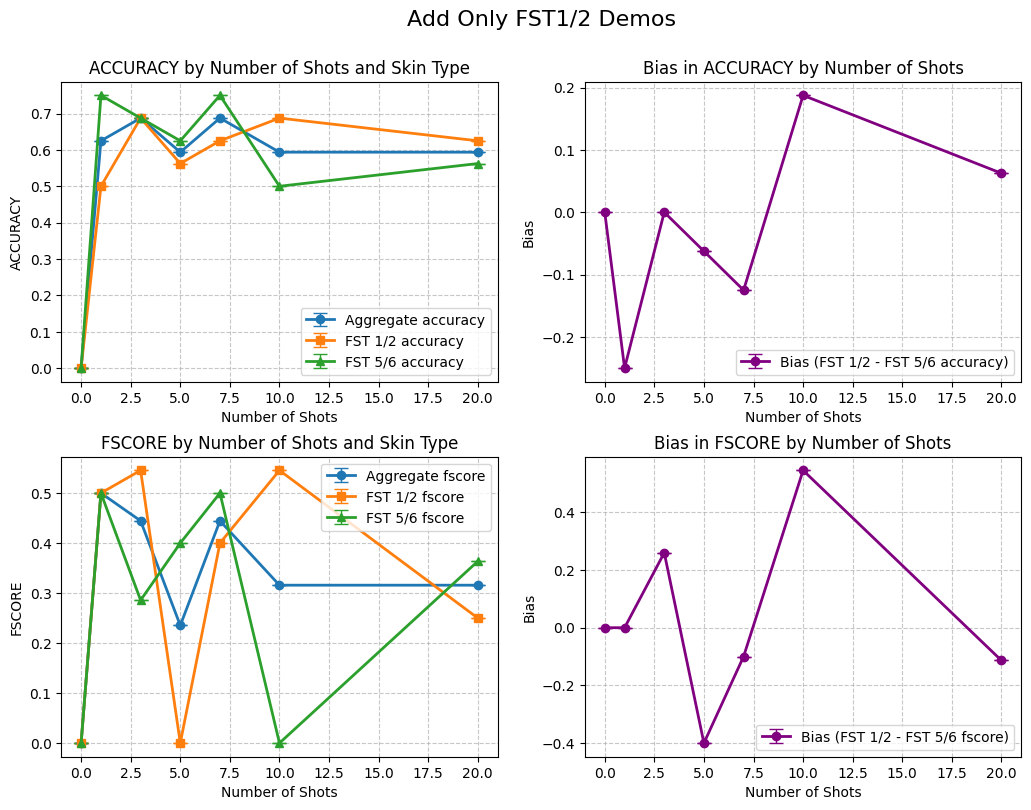

In [61]:
# Plot with confidence intervals
shots = extract_shots(numbers["fst12"])
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add Only FST1/2 Demos", 
                          use_error_bars=True)

In [ ]:
exps_list = [
    [f"{base_path}/{folder}/ddi_{num}_{model_name}_50.pkl" for num in numbers["both"]]
    for folder in rep_folders
]

bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)
print(exps_list)
# Plot with confidence intervals
# shots = extract_shots(numbers["both"][1:])
shots = numbers['other']
print(len(shots), len(exps_list[0]))
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add equal numbers FST1/2 and FST5/6 Demos", 
                          use_error_bars=True)
plot_all_avg_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add equal numbers FST1/2 and FST5/6 Demos", 
                          use_error_bars=True)


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/sonne/Downloads/baseRateExps0128/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl'

In [222]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

C:/Users/sonne/Downloads/baseRateExps0128/ddi_0_40_0_40_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/baseRateExps0128/ddi_10_30_10_30_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/baseRateExps0128/ddi_20_20_20_20_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/baseRateExps0128/ddi_30_10_30_10_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104


['0_40_0_40', '10_30_10_30', '20_20_20_20', '30_10_30_10', '40_0_40_0']
5 5
2
[{'accuracy': np.float64(0.25), 'tpr': np.float64(1.0), 'fscore': np.float64(0.4), 'avg_preds': np.float64(1.0), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.41346153846153844), 'tpr': np.float64(0.8461538461538461), 'fscore': np.float64(0.419047619047619), 'avg_preds': np.float64(0.7596153846153846), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.5096153846153846), 'tpr': np.float64(0.7692307692307693), 'fscore': np.float64(0.4395604395604395), 'avg_preds': np.float64(0.625), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.5480769230769231), 'tpr': np.float64(0.5384615384615384), 'fscore': np.float64(0.3733333333333333), 'avg_preds': np.float64(0.47115384615384615), 'avg_labels': np.float64(0.25)}] [{'accuracy': np.float64(0.23076923076923078), 'tpr': np.float64(1.0), 'fscore': np.float64(0.375), 'avg_preds': np.float64(1.0), 'avg_labels': np.float64(0.23076923076923078)}

ValueError: 'x' and 'y' must have the same size

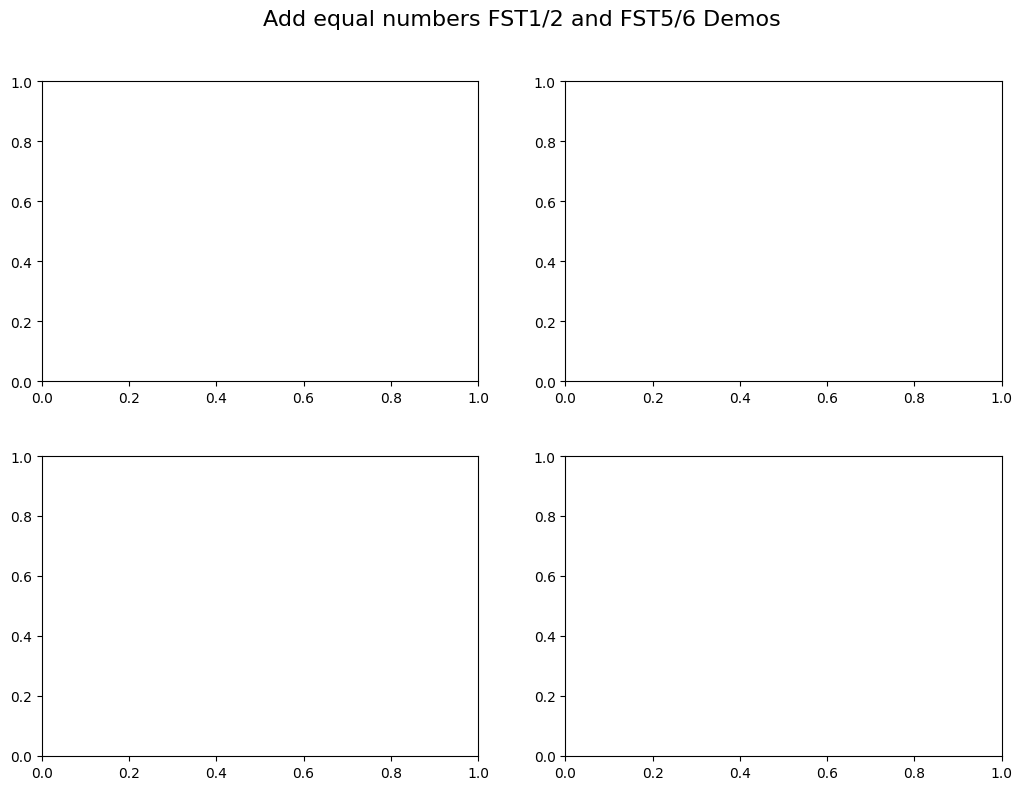

In [238]:
# # Plot with confidence intervals
# shots = extract_shots(numbers["both"])
# shots = [x * 2 for x in shots]
# plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
#                           "Add equal numbers FST1/2 and FST5/6 Demos", 
#                           use_error_bars=True)

print(numbers["both"][1:])
# Plot with confidence intervals
# shots = extract_shots(numbers["both"][1:])
# shots = ["10_30_10_30", "20_20_20_20", "30_10_30_10"]
# shots = ["0_40_0_40", "10_30_10_30", "20_20_20_20", "30_10_30_10", "40_0_40_0"]
shots = numbers['both'][1:]

print(len(shots), len(exps_list[0]))
print(len(bulk_metrics))
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add equal numbers FST1/2 and FST5/6 Demos", 
                          use_error_bars=True)
plot_all_avg_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add equal numbers FST1/2 and FST5/6 Demos", 
                          use_error_bars=True)

### Other

In [193]:
numbers

defaultdict(list,
            {'both': ['0_0_0_0',
              '0_40_0_40',
              '10_30_10_30',
              '20_20_20_20',
              '30_10_30_10',
              '40_0_40_0'],
             'other': ['0_40_40_0', '10_30_30_10', '30_10_10_30', '34_0_0_34'],
             'fst12': ['0_0_0_0'],
             'fst56': ['0_0_0_0']})

C:/Users/sonne/Downloads/invBaseRate0128/ddi_0_40_40_0_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/baseRateExps0128/ddi_0_40_40_0_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/invBaseRate0128/ddi_10_30_30_10_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/baseRateExps0128/ddi_10_30_30_10_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/invBaseRate0128/ddi_30_10_10_30_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/baseRateExps0128/ddi_30_10_10_30_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/invBaseRate0128/ddi_34_0_0_34_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
C:/Users/sonne/Downloads/baseRateExps0128/ddi_34_0_0_34_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 104
[['C:/Users/sonne/Downloads/invBaseRate0128/ddi_0_40_40_0_gpt-4o-2024-05-13_50.pkl', 'C:/Users/sonne/Downloads/invBaseRate01

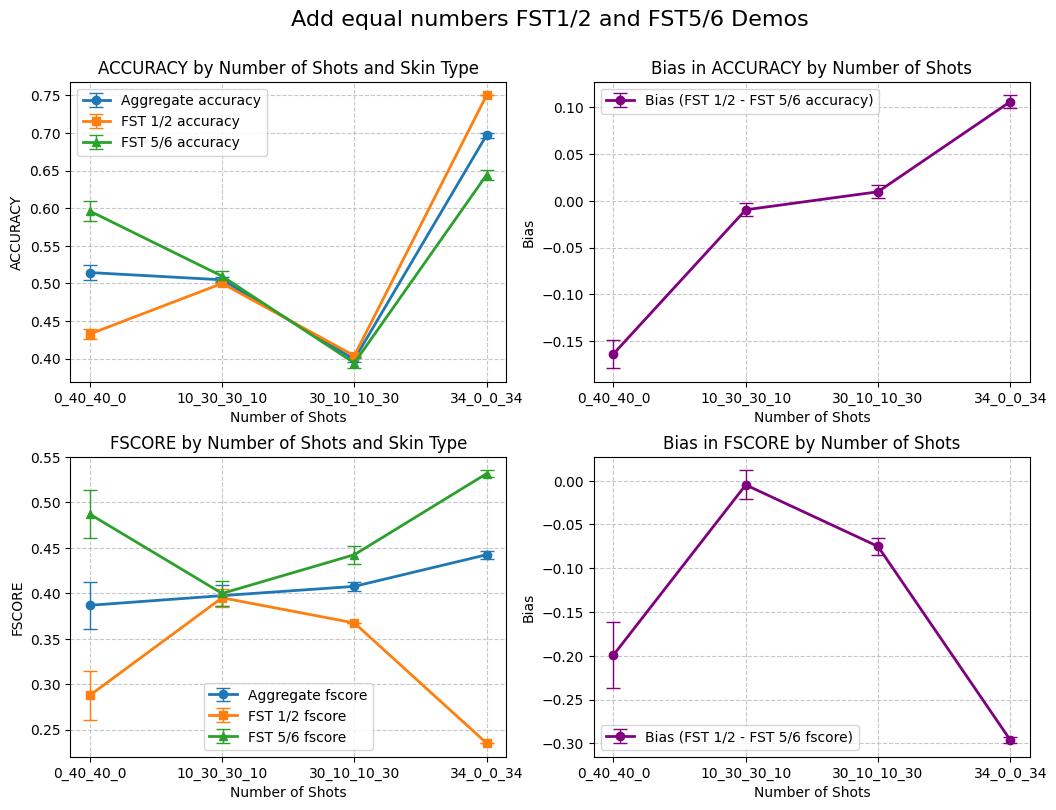

[{'accuracy': np.float64(0.5144230769230769), 'tpr': np.float64(0.6153846153846154), 'fscore': np.float64(0.38676470588235295), 'avg_preds': np.float64(0.5432692307692308), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.5048076923076923), 'tpr': np.float64(0.6538461538461539), 'fscore': np.float64(0.3973727422003284), 'avg_preds': np.float64(0.5721153846153846), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.39903846153846156), 'tpr': np.float64(0.8269230769230769), 'fscore': np.float64(0.4075471698113208), 'avg_preds': np.float64(0.7644230769230769), 'avg_labels': np.float64(0.25)}, {'accuracy': np.float64(0.6971153846153846), 'tpr': np.float64(0.4807692307692308), 'fscore': np.float64(0.4423197492163009), 'avg_preds': np.float64(0.2932692307692308), 'avg_labels': np.float64(0.25)}] [{'accuracy': np.float64(0.4326923076923077), 'tpr': np.float64(0.5), 'fscore': np.float64(0.28779069767441856), 'avg_preds': np.float64(0.5673076923076923), 'avg_labels': np.float6

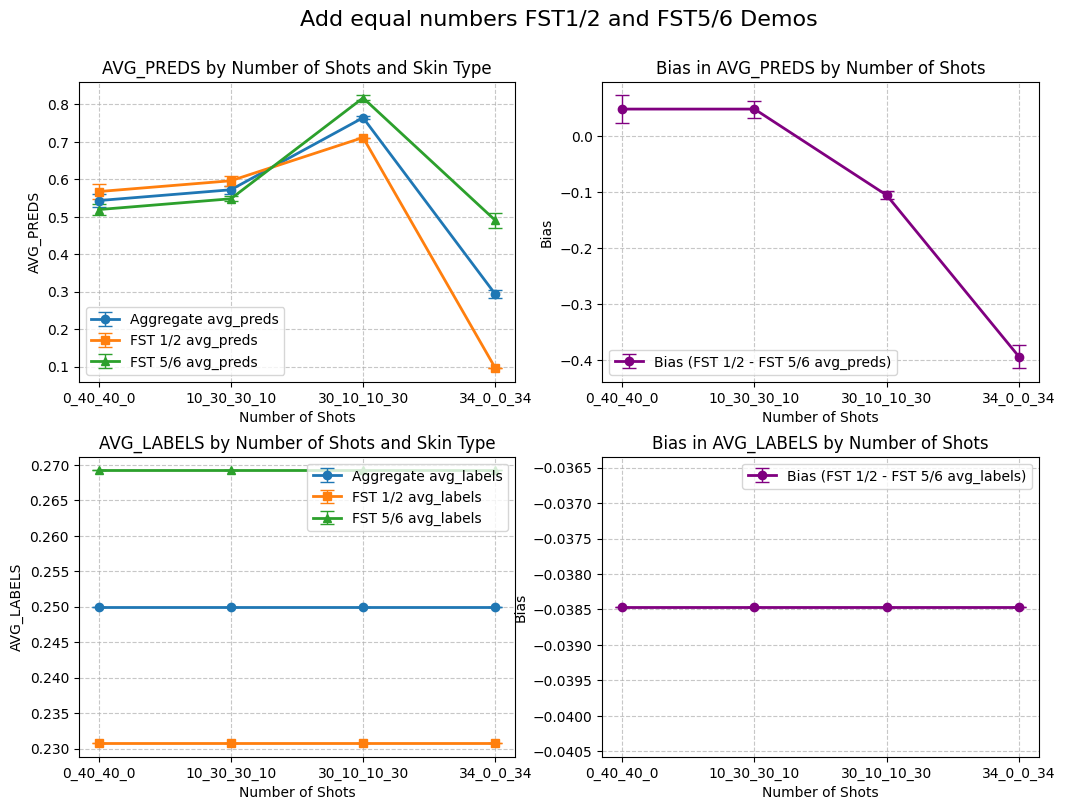

In [246]:
exps_list = [
    [f"{base_path}/{folder}/ddi_{num}_{model_name}_50.pkl" for num in numbers["other"]]
    for folder in rep_folders
]

bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)
print(exps_list)
# Plot with confidence intervals
# shots = extract_shots(numbers["both"][1:])
shots = numbers['other']
print(len(shots), len(exps_list[0]))
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add equal numbers FST1/2 and FST5/6 Demos", 
                          use_error_bars=True)
plot_all_avg_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add equal numbers FST1/2 and FST5/6 Demos", 
                          use_error_bars=True)


In [132]:
print(bulk_metrics, fst12_metrics, fst56_metrics)

{'mean': [{'accuracy': np.float64(0.34615384615384615), 'tpr': np.float64(0.8846153846153846), 'fscore': np.float64(0.4035087719298246)}, {'accuracy': np.float64(0.49038461538461536), 'tpr': np.float64(0.7692307692307693), 'fscore': np.float64(0.43010752688172044)}, {'accuracy': np.float64(0.49038461538461536), 'tpr': np.float64(0.5769230769230769), 'fscore': np.float64(0.3614457831325302)}], 'stderr': [{'accuracy': np.float64(0.0), 'tpr': np.float64(0.0), 'fscore': np.float64(0.0)}, {'accuracy': np.float64(0.0), 'tpr': np.float64(0.0), 'fscore': np.float64(0.0)}, {'accuracy': np.float64(0.0), 'tpr': np.float64(0.0), 'fscore': np.float64(0.0)}]} {'mean': [{'accuracy': np.float64(0.38461538461538464), 'tpr': np.float64(0.9166666666666666), 'fscore': np.float64(0.4074074074074074)}, {'accuracy': np.float64(0.4230769230769231), 'tpr': np.float64(0.6666666666666666), 'fscore': np.float64(0.3478260869565218)}, {'accuracy': np.float64(0.46153846153846156), 'tpr': np.float64(0.5), 'fscore': n